In [ ]:
words = open("names.txt", "r").read().splitlines()
len(words)
import torch
import matplotlib.pyplot as plt

%matplotlib inline
import torch.nn.functional as F

# 构建映射
chars = sorted(list(set("".join(words))))
stoi = {".": 0}
stoi.update({s: i + 1 for i, s in enumerate(chars)})
itos = {i: s for s, i in stoi.items()}

# 训练样本
block_size = 3
xs, ys = [[], [], []], []
for w in words:
    chs = [".", ".", "."] + list(w) + ["."]
    for ch1, ch2, ch3, ch4 in zip(chs, chs[1:], chs[2:], chs[3:]):
        xs[0].append(stoi[ch1])
        xs[1].append(stoi[ch2])
        xs[2].append(stoi[ch3])
        ys.append(stoi[ch4])

vocab_size = len(stoi)
X = torch.tensor(xs).t().contiguous()  # 注意转置
ys = torch.tensor(ys)
N = len(ys)

# 生成器
g = torch.Generator().manual_seed(2147483647)

# embedding metrix
embedding_dim = 10
C = torch.randn((vocab_size, embedding_dim), generator=g, requires_grad=True)

# 权重和偏置
hidden_size = 200
W1 = torch.randn(
    (block_size * embedding_dim, hidden_size), generator=g, requires_grad=True
)
b1 = torch.randn((hidden_size,), generator=g, requires_grad=True)
W2 = torch.randn((hidden_size, vocab_size), generator=g, requires_grad=True)
b2 = torch.randn((vocab_size,), generator=g, requires_grad=True)

parameters = [C, W1, b1, W2, b2]
num_parameters = sum(p.nelement() for p in parameters)


Text(0, 0.5, 'loss')

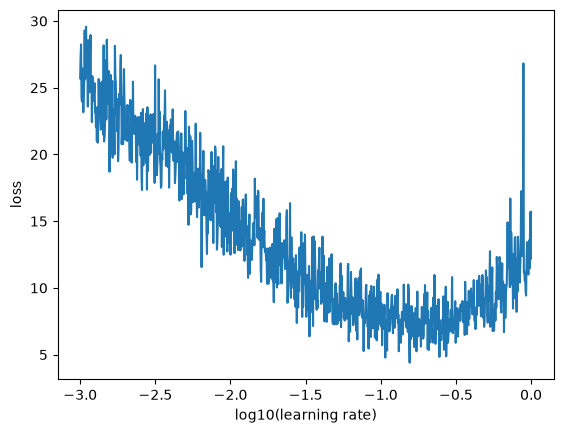

In [ ]:
# 学习率扫描:找一个较优的学习率范围
lre = torch.linspace(-3, 0, 1000)  # 生成1000个指数,从-3到0
lrs = 10**lre  # 对应学习率从0.001到1,指数增长

lri = []  # 记录每一步用的学习率(取log,方便画图)
lossi = []  # 记录每一步的loss

for i in range(1000):
    # 随机采样一个batch
    ix = torch.randint(0, X.shape[0], (32,), generator=g)

    # forward
    emb = C[X[ix]]
    h = torch.tanh(emb.view(emb.shape[0], -1) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, ys[ix])

    # backward
    for p in parameters:
        p.grad = None
    loss.backward()

    # 用这一步对应的学习率更新
    lr = lrs[i]
    for p in parameters:
        p.data += -lr * p.grad

    # 记录
    lri.append(lre[i].item())
    lossi.append(loss.item())

plt.plot(lri, lossi)
plt.xlabel("log10(learning rate)")
plt.ylabel("loss")

In [ ]:
# 选一个较优的学习率
# 先重制参数
embedding_dim = 10
C = torch.randn((vocab_size, embedding_dim), generator=g, requires_grad=True)

# 权重和偏置
hidden_size = 200
W1 = torch.randn(
    (block_size * embedding_dim, hidden_size), generator=g, requires_grad=True
)
b1 = torch.randn((hidden_size,), generator=g, requires_grad=True)
W2 = torch.randn((hidden_size, vocab_size), generator=g, requires_grad=True)
b2 = torch.randn((vocab_size,), generator=g, requires_grad=True)

parameters = [C, W1, b1, W2, b2]
num_parameters = sum(p.nelement() for p in parameters)


(1.474874496459961, 1.7375725507736206)

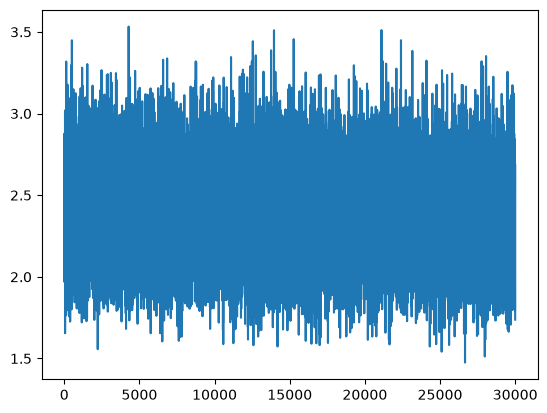

In [ ]:
# 循环训练
iters = 30000
alpha = 0.1
list_loss = []
batch_size = 32
for i in range(iters):
    # 随机采样
    ix = torch.randint(0, X.shape[0], (batch_size,), generator=g)
    # forward
    emb = C[X[ix]]  # N,block_size,embedding_dim
    # 拉平
    emb_flat = emb.view(emb.shape[0], -1)  # N,block_size*embedding_dim
    z1 = emb_flat @ W1 + b1
    a1 = F.tanh(z1)
    logits = a1 @ W2 + b2
    loss = F.cross_entropy(logits, ys[ix])
    """
    probs=F.softmax(logits,dim=1)
    loss=-prob[range(N),ys].log().mean()
    """
    # backward
    for p in parameters:
        p.grad = None
    loss.backward()

    for p in parameters:
        p.data += -alpha * p.grad

    list_loss.append(loss.item())

plt.plot(list_loss)
min(list_loss), list_loss[-1]

2.3422739505767822


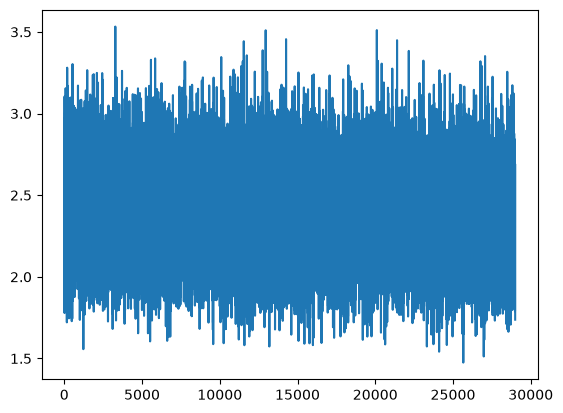

In [10]:
with torch.no_grad():
    emb = C[X]
    h = torch.tanh(emb.view(emb.shape[0], -1) @ W1 + b1)
    logits = h @ W2 + b2
    print(F.cross_entropy(logits, ys).item())
plt.plot(list_loss[1000:])

In [ ]:
g_sample = torch.Generator().manual_seed(420)
for _ in range(15):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]  # 注意这里context外面还有一层【】
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        prob = F.softmax(logits, dim=1)
        ix = torch.multinomial(prob, num_samples=1, generator=g_sample).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print("".join(itos[i] for i in out))

railean.
lez.
mellinnelin.
chellen.
zaylinannell.
anjier.
mern.
man.
alemoziel.
cachamellien.
dun.
kamaraelynn.
panstwellejondyannia.
haann.
nareellanna.


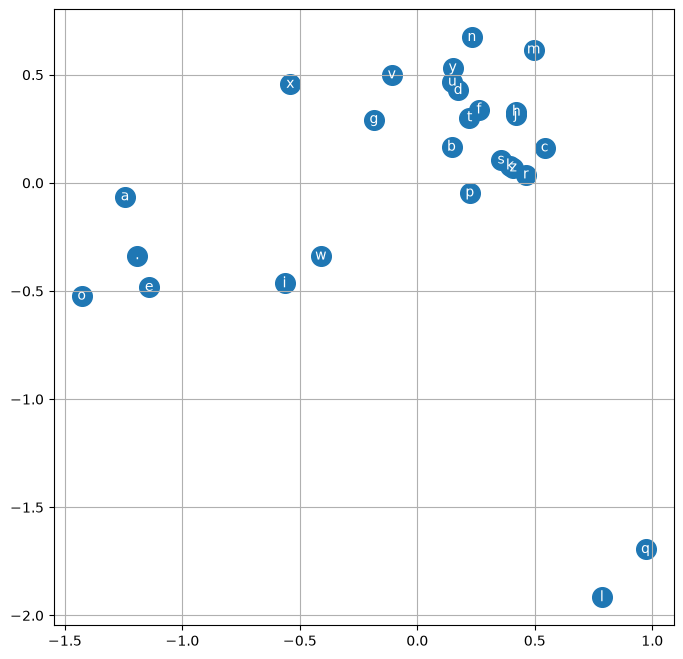

In [ ]:
# PCA/SVD来可视化
import numpy as np

C_np = C.detach().numpy()
C_centered = C_np - C_np.mean(axis=0)
U, S, Vt = np.linalg.svd(C_centered)
C_2d = C_centered @ Vt[:2].T

# 可视化:
plt.figure(figsize=(8, 8))
plt.scatter(C_2d[:, 0], C_2d[:, 1], s=200)
for i in range(vocab_size):
    plt.text(C_2d[i, 0], C_2d[i, 1], itos[i], ha="center", va="center", color="white")
plt.grid(True)
plt.show()